Ejemplo básico de teleportación:

In [18]:
import pyzx as zx
import matplotlib.pyplot as plt
from pyzx.simplify import *
def teleport_graph():

    circ = zx.Circuit(3)
    circ.add_gate("H", 1)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CNOT", 0, 1)
    circ.add_gate("H", 0)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CZ", 0, 2)

    g = circ.to_graph()

    # Extraer los nodos frontera
    entradas = g.inputs()
    salidas = g.outputs()

    # 1. INICIALIZACIÓN DEL RECURSO ENTRELAZADO (Inputs al estado |0>)
    g.set_type(entradas[1], zx.VertexType.X)
    g.set_type(entradas[2], zx.VertexType.X)

    # 2. PROYECCIONES DE MEDIDA (Colapso del Pauli Frame)
    # Salida 0: Al tener una puerta H previa, proyectar a <+| equivale a medir <0|
    g.set_type(salidas[0], zx.VertexType.X)
    # Salida 1: Proyección directa a <0| (Medida en la base Z)
    g.set_type(salidas[1], zx.VertexType.X)
    return g

# Dibujar el grafo preparatorio
graph = teleport_graph()
zx.draw(graph)


In [20]:
opt_graph = teleport_graph()

while True:
    i1 = id_simp(opt_graph)
    if i1: 
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    i2 = spider_simp(opt_graph)
    if i2:         
            fig = zx.draw(opt_graph)
            print("i2")
            display(fig)
            plt.close(fig)
    i3 = pivot_simp(opt_graph)
    if i3:           
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    if not (i1 or i2 or i3): break

while True:
    i4 = lcomp_simp(opt_graph)
    if i4: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i4")
        display(fig)
        plt.close(fig)
    i5 = pivot_boundary_simp(opt_graph)
    if i5: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i5")
        display(fig)
        plt.close(fig)
    i6 = gadget_simp(opt_graph)
    if i6:
        fig = zx.draw(opt_graph)
        print("i6")
        display(fig)
        plt.close(fig)
    i7 = pivot_gadget_simp(opt_graph)
    if i7:
        fig = zx.draw(opt_graph)
        print("i7")
        display(fig)
        plt.close(fig)
    i8 = clifford_simp(opt_graph)
    if i8:
        fig = zx.draw(opt_graph)
        print("i8")
        display(fig)
        plt.close(fig)
    if not (i4 or i5 or i6 or i7 or i8): break

i1


None

i2


None

i8


None

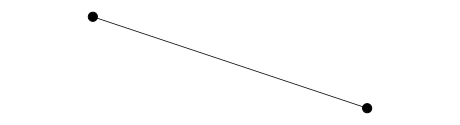

In [12]:
full_opt_graph = teleport_graph()
zx.simplify.full_reduce(full_opt_graph)
optimized_circ = zx.extract_circuit(full_opt_graph)
zx.draw_matplotlib(full_opt_graph)